In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ============================================================
# PROJECT: Retail Demand Forecasting & Inventory Optimization
# PHASE 1 : EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

In [3]:
sales = pd.read_csv("Sales_Data.csv")
products = pd.read_csv("Products_Data.csv")
warehouses = pd.read_csv("Warehouses_Data.csv")
inventory = pd.read_csv("Inventory_Data.csv")
suppliers = pd.read_csv("Suppliers_Data.csv")
calendar = pd.read_csv("Calendar_Data.csv")

In [4]:
# Check shape of every table

datasets = {
    "Sales": sales,
    "Products": products,
    "Warehouses": warehouses,
    "Inventory": inventory,
    "Suppliers": suppliers,
    "Calendar": calendar
}

for name, df in datasets.items():
    print("\n", "="*50)
    print(name)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])


Sales
Rows: 200000
Columns: 10

Products
Rows: 200
Columns: 8

Warehouses
Rows: 5
Columns: 4

Inventory
Rows: 1000
Columns: 6

Suppliers
Rows: 15
Columns: 4

Calendar
Rows: 1096
Columns: 6


In [5]:
for name, df in datasets.items():

    print("\n", "="*50)
    print(name)

    display(df.info())


Sales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  object 
 1   Order_Date     200000 non-null  object 
 2   Product_ID     200000 non-null  object 
 3   Customer_ID    200000 non-null  object 
 4   Store_ID       200000 non-null  object 
 5   Quantity_Sold  200000 non-null  int64  
 6   Unit_Price     200000 non-null  float64
 7   Discount       200000 non-null  float64
 8   Sales          200000 non-null  float64
 9   Profit         200000 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 15.3+ MB


None


Products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     200 non-null    object 
 1   Product_Name   200 non-null    object 
 2   Category       200 non-null    object 
 3   Subcategory    200 non-null    object 
 4   Brand          200 non-null    object 
 5   Cost_Price     200 non-null    float64
 6   Selling_Price  200 non-null    float64
 7   Supplier_ID    200 non-null    object 
dtypes: float64(2), object(6)
memory usage: 12.6+ KB


None


Warehouses
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Warehouse_ID  5 non-null      object
 1   City          5 non-null      object
 2   State         5 non-null      object
 3   Capacity      5 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 292.0+ bytes


...

None


Suppliers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Supplier_ID      15 non-null     object 
 1   Supplier_Name    15 non-null     object 
 2   Lead_Time        15 non-null     int64  
 3   Delivery_Rating  15 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 612.0+ bytes


None


Calendar
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          1096 non-null   object
 1   Month         1096 non-null   object
 2   Quarter       1096 non-null   object
 3   Week          1096 non-null   int64 
 4   Year          1096 non-null   int64 
 5   Holiday_Flag  1096 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 51.5+ KB


None

In [6]:
for name, df in datasets.items():

    print(name, "Duplicates:", df.duplicated().sum())

Sales Duplicates: 0
Products Duplicates: 0
Warehouses Duplicates: 0
Inventory Duplicates: 0
Suppliers Duplicates: 0
Calendar Duplicates: 0


In [7]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
# ------------------------------------------------------------
# 1. BASIC STRUCTURE CHECKS
# ------------------------------------------------------------
datasets = {
    "Sales": sales,
    "Products": products,
    "Warehouses": warehouses,
    "Inventory": inventory,
    "Suppliers": suppliers,
    "Calendar": calendar
}

for name, df in datasets.items():
    print(f"\n{'='*50}\n{name} Data\n{'='*50}")
    print("Shape:", df.shape)
    print(df.info())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())



Sales Data
Shape: (200000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  object 
 1   Order_Date     200000 non-null  object 
 2   Product_ID     200000 non-null  object 
 3   Customer_ID    200000 non-null  object 
 4   Store_ID       200000 non-null  object 
 5   Quantity_Sold  200000 non-null  int64  
 6   Unit_Price     200000 non-null  float64
 7   Discount       200000 non-null  float64
 8   Sales          200000 non-null  float64
 9   Profit         200000 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 15.3+ MB
None

Missing Values:
 Order_ID         0
Order_Date       0
Product_ID       0
Customer_ID      0
Store_ID         0
Quantity_Sold    0
Unit_Price       0
Discount         0
Sales            0
Profit           0
dtype: int64

Duplicate Rows: 0

Products

In [9]:
# ------------------------------------------------------------
# 2. DATE CONVERSIONS (important before analysis)
# ------------------------------------------------------------
sales['Order_Date'] = pd.to_datetime(sales['Order_Date'])
calendar['Date'] = pd.to_datetime(calendar['Date'])

In [10]:
# ------------------------------------------------------------
# 3. STATISTICAL SUMMARY
# ------------------------------------------------------------
print("Sales : ")
print(sales.describe())

print("="*50)

print("Products : ")
print(products[['Cost_Price', 'Selling_Price']].describe())

print("="*50)

print("Inventory : ")
print(inventory.describe())

print("="*50)

print("Suppliers : ")
print(suppliers.describe())

Sales : 
       Quantity_Sold     Unit_Price       Discount          Sales  \
count  200000.000000  200000.000000  200000.000000  200000.000000   
mean        3.186725     302.169415       0.047046     911.080723   
std         1.890779     189.138060       0.061336     825.949506   
min         1.000000       9.480000       0.000000       8.060000   
25%         2.000000     138.730000       0.000000     304.170000   
50%         3.000000     300.370000       0.000000     654.190000   
75%         4.000000     457.290000       0.100000    1310.500000   
max        15.000000     767.610000       0.250000   10362.740000   

              Profit  
count  200000.000000  
mean      363.099433  
std       360.469899  
min       -71.430000  
25%       105.960000  
50%       244.600000  
75%       503.240000  
max      5120.690000  
Products : 
       Cost_Price  Selling_Price
count  200.000000      200.00000
mean   171.746400      302.20160
std    104.181003      189.88685
min      5.740000 

In [11]:
# ------------------------------------------------------------
# 4. DATA QUALITY CHECKS : Checks to identify invalid or suspicious values in your dataset 
#                          before you begin analysis or forecasting
# ------------------------------------------------------------
# Negative / zero values check
print("Negative Quantity_Sold:", (sales['Quantity_Sold'] <= 0).sum())
print("Negative Sales:", (sales['Sales'] < 0).sum())
print("Negative Profit:", (sales['Profit'] < 0).sum())
print("Discount > 1 (invalid %):", (sales['Discount'] > 1).sum())

Negative Quantity_Sold: 0
Negative Sales: 0
Negative Profit: 80
Discount > 1 (invalid %): 0


In [12]:
# Check for orphan Product_IDs / Store references
invalid_products = sales[~sales['Product_ID'].isin(products['Product_ID'])]
print("Sales rows with invalid Product_ID:", invalid_products.shape[0])

Sales rows with invalid Product_ID: 0


In [13]:
# ------------------------------------------------------------
# 5. UNIVARIATE ANALYSIS
# ------------------------------------------------------------

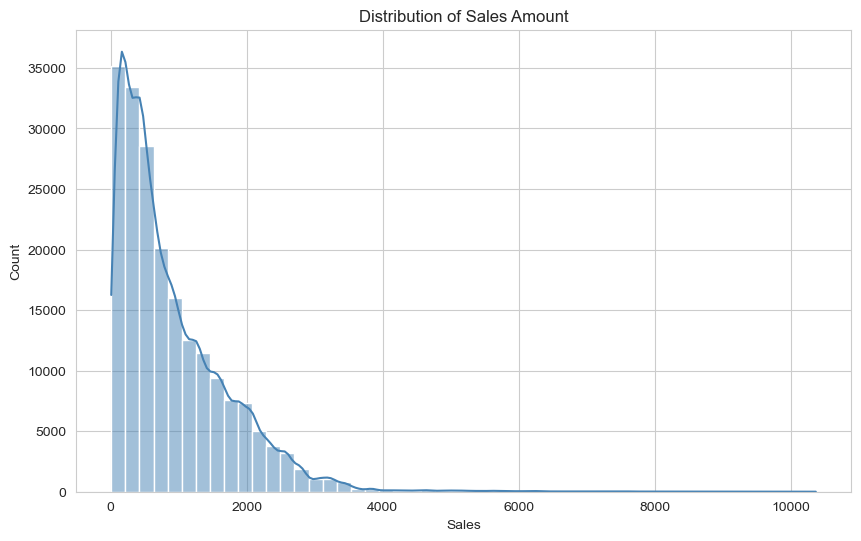

In [14]:
# 5.1 Sales distribution
plt.figure()
sns.histplot(sales['Sales'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales")
plt.show()

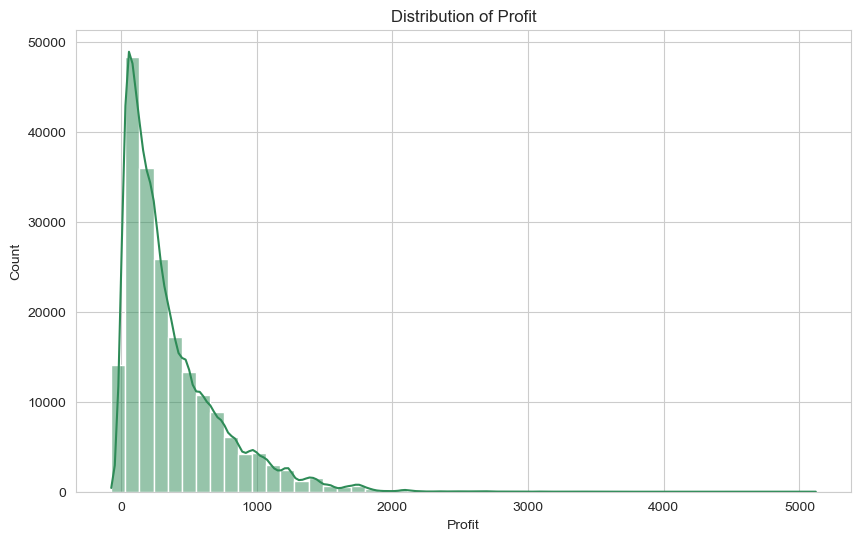

In [15]:
# 5.2 Profit distribution
plt.figure()
sns.histplot(sales['Profit'], bins=50, kde=True, color='seagreen')
plt.title("Distribution of Profit")
plt.show()

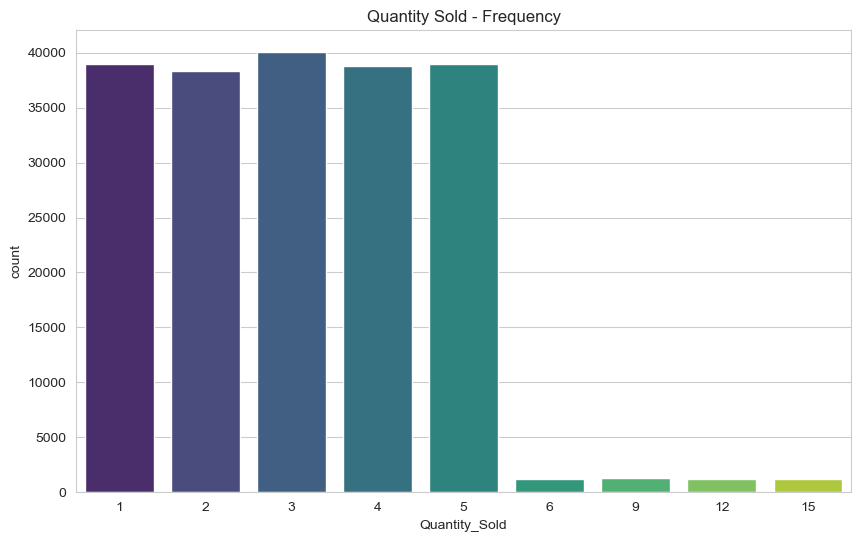

In [16]:
# 5.3 Quantity Sold distribution
plt.figure()
sns.countplot(x='Quantity_Sold', data=sales, palette='viridis')
plt.title("Quantity Sold - Frequency")
plt.show()

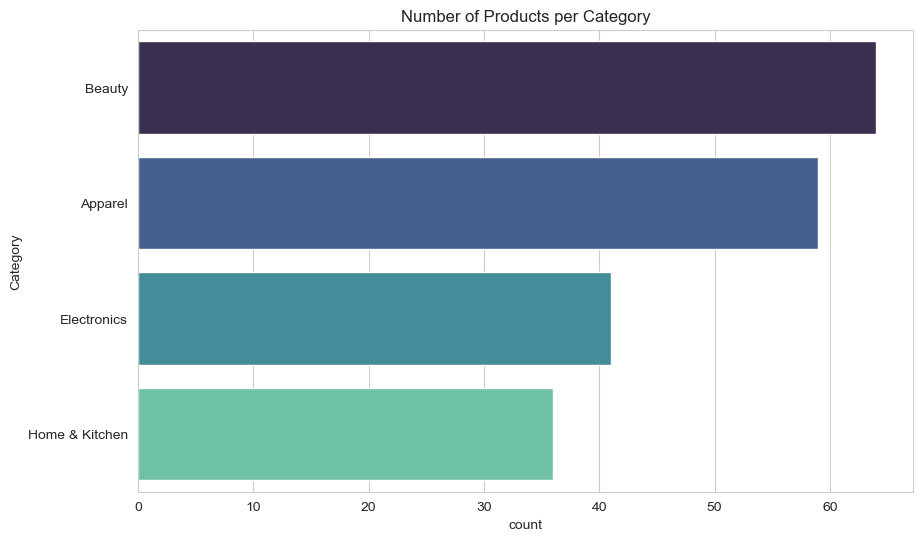

In [17]:
# 5.4 Category-wise product count
plt.figure()
sns.countplot(y='Category', data=products, order=products['Category'].value_counts().index, palette='mako')
plt.title("Number of Products per Category")
plt.show()

In [18]:
# ------------------------------------------------------------
# 6. TIME-SERIES / TREND ANALYSIS
# ------------------------------------------------------------

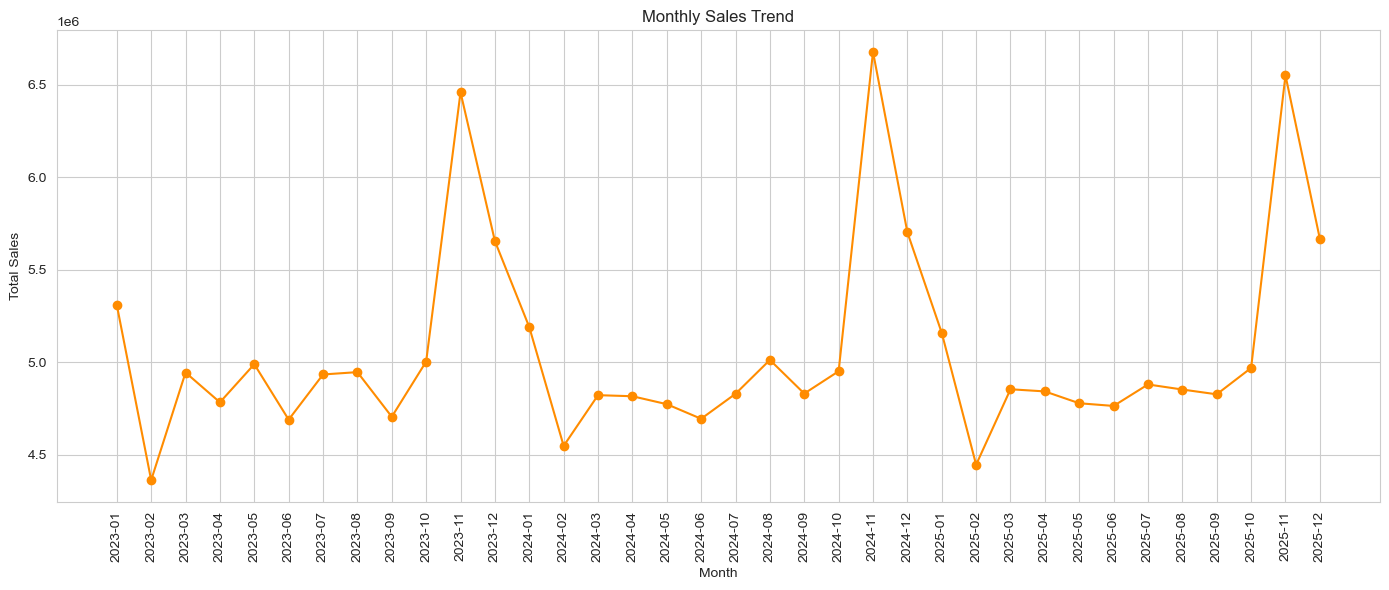

In [19]:
# 6.1 Monthly Sales Trend
sales['Order_Month'] = sales['Order_Date'].dt.to_period('M')
monthly_sales = sales.groupby('Order_Month')['Sales'].sum().reset_index()
monthly_sales['Order_Month'] = monthly_sales['Order_Month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Order_Month'], monthly_sales['Sales'], marker='o', color='darkorange')
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

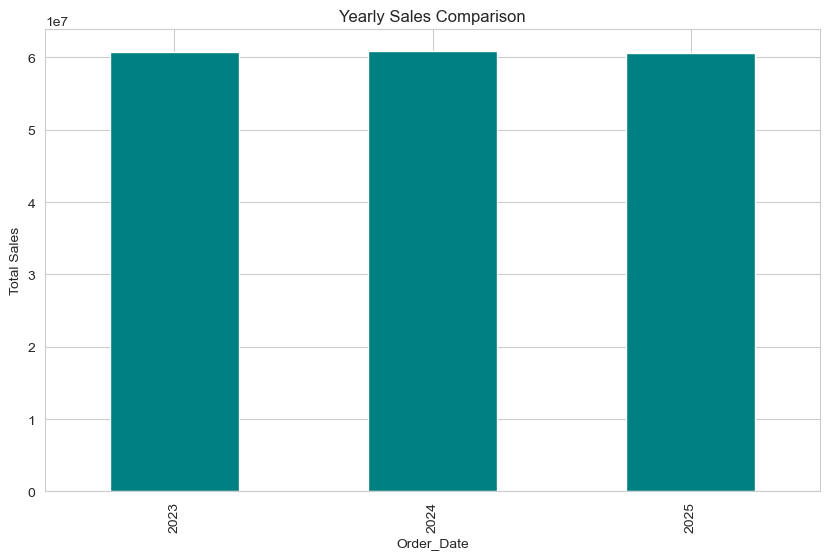

In [20]:
# 6.2 Year-wise Sales
yearly_sales = sales.groupby(sales['Order_Date'].dt.year)['Sales'].sum()
plt.figure()
yearly_sales.plot(kind='bar', color='teal')
plt.title("Yearly Sales Comparison")
plt.ylabel("Total Sales")
plt.show()

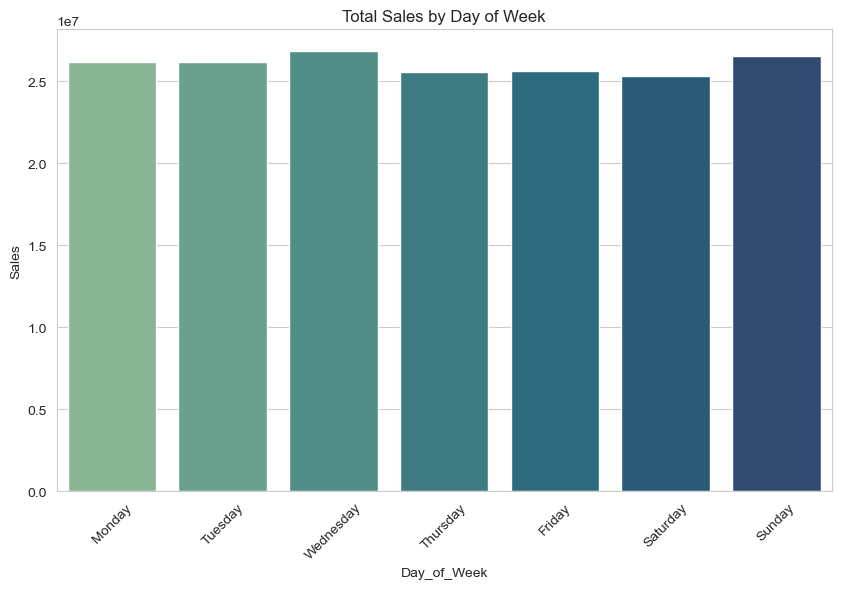

In [21]:
# 6.3 Sales by Day of Week
sales['Day_of_Week'] = sales['Order_Date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure()
sns.barplot(x='Day_of_Week', y='Sales', data=sales, order=dow_order, estimator=sum, errorbar=None, palette='crest')
plt.title("Total Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

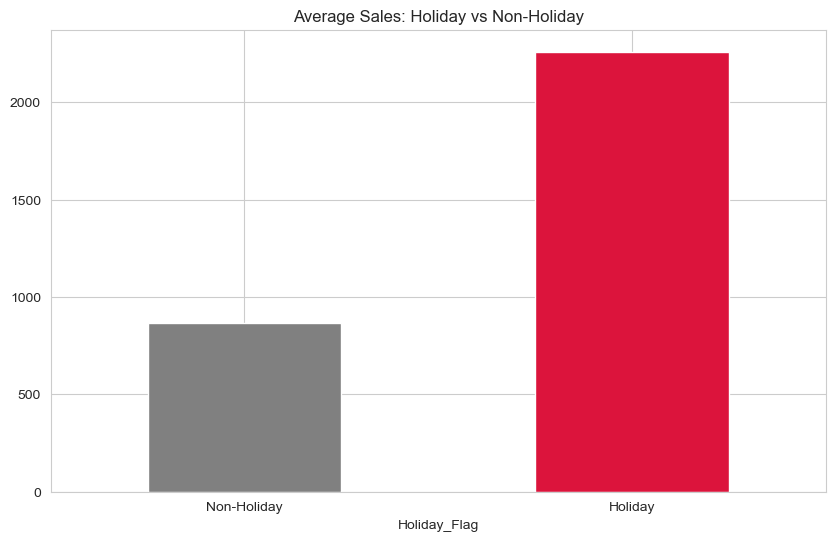

In [22]:
# 6.4 Holiday impact on Sales (merge with Calendar)
sales_calendar = sales.merge(calendar, left_on='Order_Date', right_on='Date', how='left')
holiday_sales = sales_calendar.groupby('Holiday_Flag')['Sales'].mean()
plt.figure()
holiday_sales.plot(kind='bar', color=['gray','crimson'])
plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xticks([0,1], ['Non-Holiday','Holiday'], rotation=0)
plt.show()

In [23]:
# ------------------------------------------------------------
# 7. PRODUCT & CATEGORY ANALYSIS
# ------------------------------------------------------------

In [24]:
# 7.1 Merge sales with product info
sales_products = sales.merge(products, on='Product_ID', how='left')

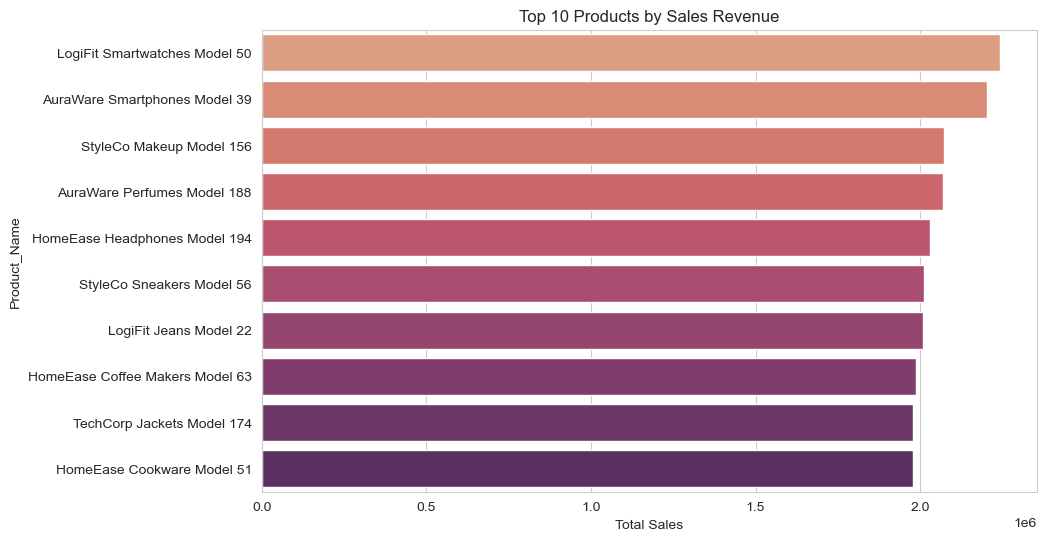

In [25]:
# 7.2 Top 10 products by revenue
top_products = sales_products.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top_products.values, y=top_products.index, palette='flare')
plt.title("Top 10 Products by Sales Revenue")
plt.xlabel("Total Sales")
plt.show()

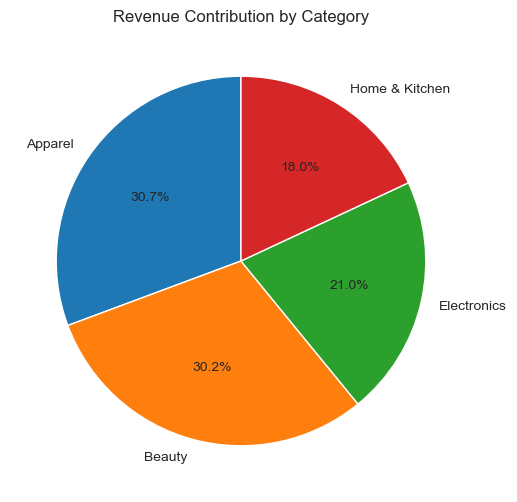

In [26]:
# 7.3 Category-wise revenue contribution
category_sales = sales_products.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure()
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title("Revenue Contribution by Category")
plt.show()

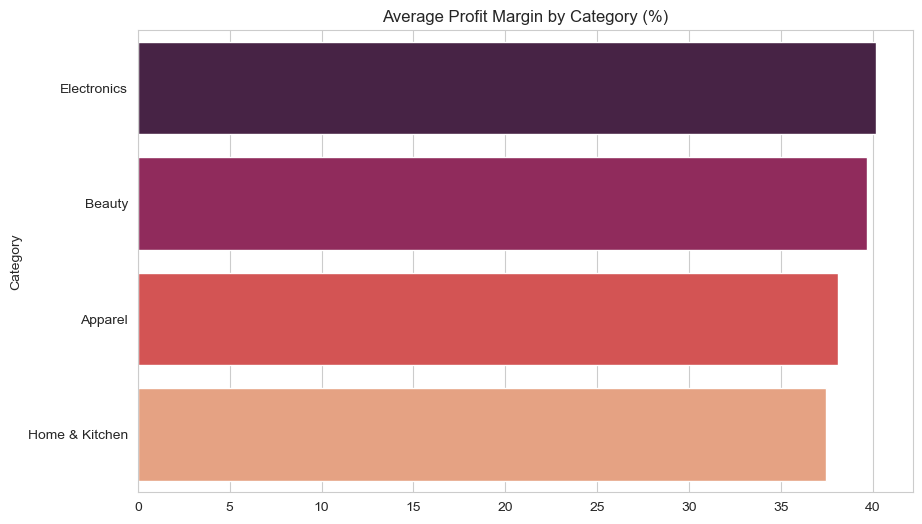

In [27]:
# 7.4 Profit Margin analysis
sales_products['Profit_Margin'] = (sales_products['Profit'] / sales_products['Sales']) * 100
category_margin = sales_products.groupby('Category')['Profit_Margin'].mean().sort_values(ascending=False)
plt.figure()
sns.barplot(x=category_margin.values, y=category_margin.index, palette='rocket')
plt.title("Average Profit Margin by Category (%)")
plt.show()

In [28]:
# ------------------------------------------------------------
# 8. STORE / WAREHOUSE ANALYSIS
# ------------------------------------------------------------

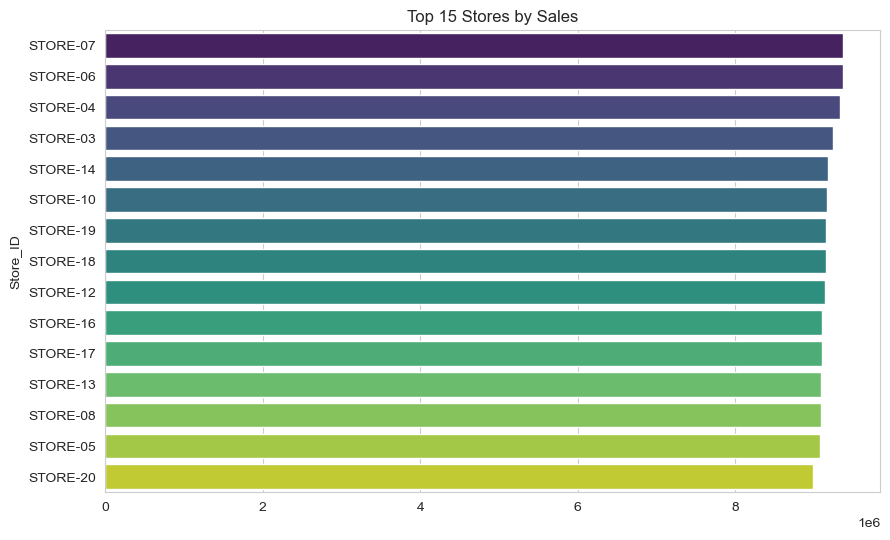

In [29]:
# 8.1 Sales by Store
store_sales = sales.groupby('Store_ID')['Sales'].sum().sort_values(ascending=False).head(15)
plt.figure()
sns.barplot(x=store_sales.values, y=store_sales.index, palette='viridis')
plt.title("Top 15 Stores by Sales")
plt.show()

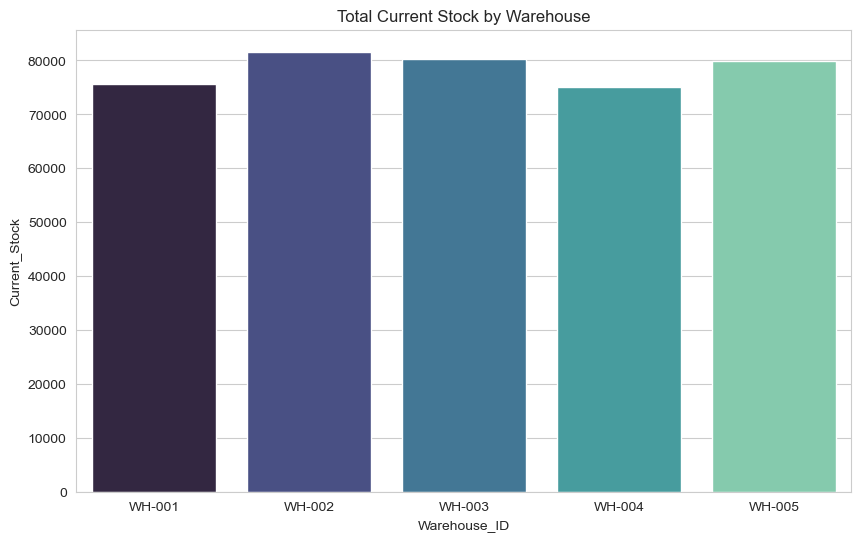

In [30]:
# 8.2 Warehouse capacity vs current stock utilization
inv_wh = inventory.merge(warehouses, on='Warehouse_ID', how='left')
wh_stock = inv_wh.groupby(['Warehouse_ID','City'])['Current_Stock'].sum().reset_index()
wh_capacity = warehouses.set_index('Warehouse_ID')['Capacity']

plt.figure()
sns.barplot(x='Warehouse_ID', y='Current_Stock', data=wh_stock, palette='mako')
plt.title("Total Current Stock by Warehouse")
plt.show()

In [31]:
# ------------------------------------------------------------
# 9. INVENTORY ANALYSIS
# ------------------------------------------------------------

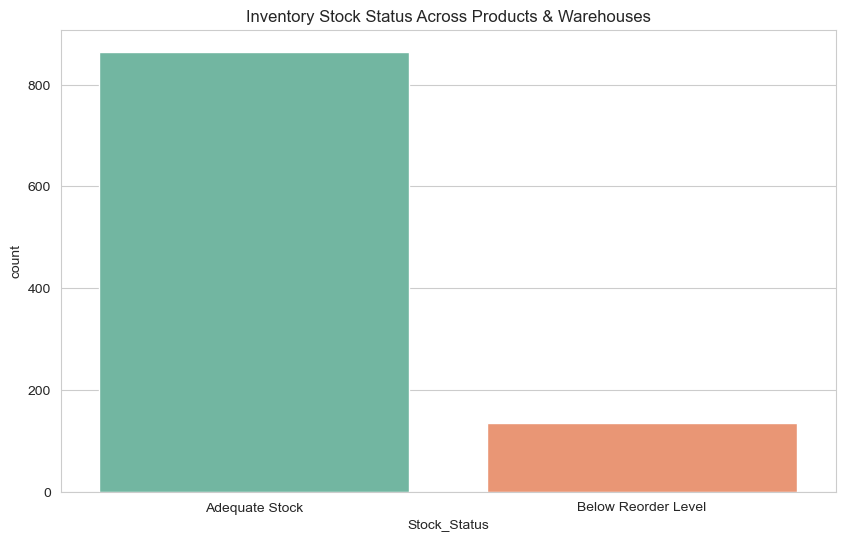

In [32]:
# 9.1 Stock vs Reorder Level (identify at-risk products)
inventory['Stock_Status'] = np.where(
    inventory['Current_Stock'] <= inventory['Reorder_Level'],
    'Below Reorder Level', 'Adequate Stock'
)
plt.figure()
sns.countplot(x='Stock_Status', data=inventory, palette='Set2')
plt.title("Inventory Stock Status Across Products & Warehouses")
plt.show()

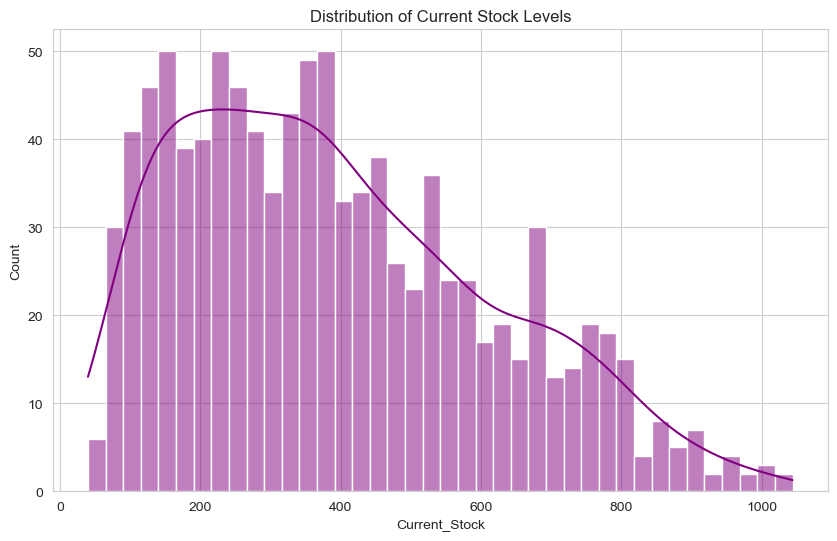

In [33]:
# 9.2 Distribution of Current Stock
plt.figure()
sns.histplot(inventory['Current_Stock'], bins=40, kde=True, color='purple')
plt.title("Distribution of Current Stock Levels")
plt.show()

In [34]:
# ------------------------------------------------------------
# 10. SUPPLIER ANALYSIS
# ------------------------------------------------------------

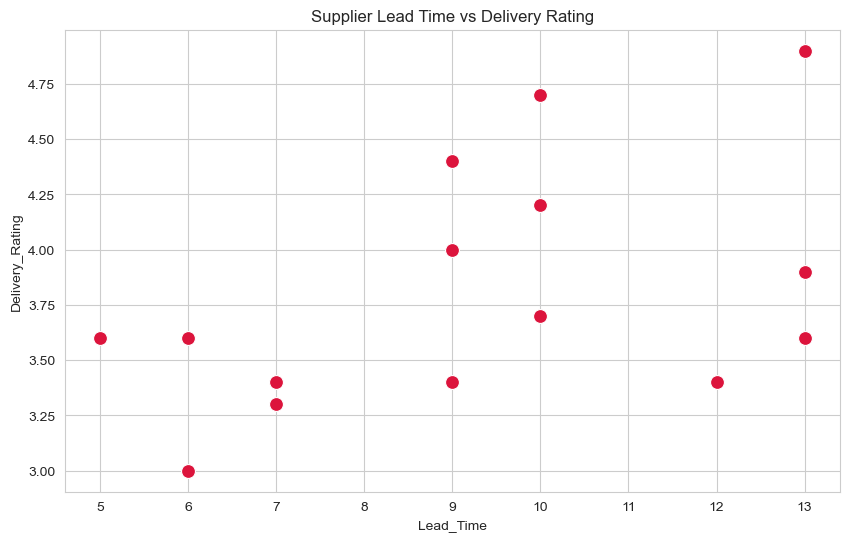

In [35]:
# 10.1 Lead Time vs Delivery Rating
plt.figure()
sns.scatterplot(x='Lead_Time', y='Delivery_Rating', data=suppliers, s=100, color='crimson')
plt.title("Supplier Lead Time vs Delivery Rating")
plt.show()

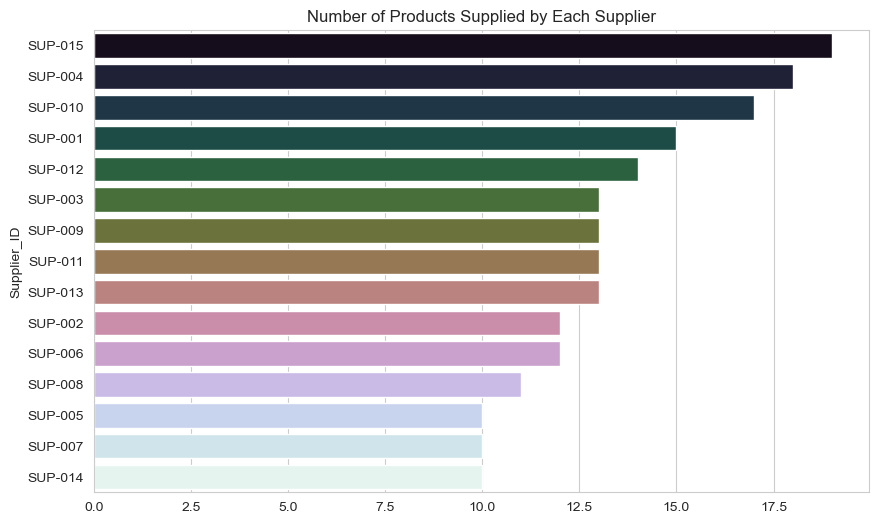

In [36]:
# 10.2 Product count per supplier
supplier_products = products.groupby('Supplier_ID')['Product_ID'].count().sort_values(ascending=False)
plt.figure()
sns.barplot(x=supplier_products.values, y=supplier_products.index, palette='cubehelix')
plt.title("Number of Products Supplied by Each Supplier")
plt.show()

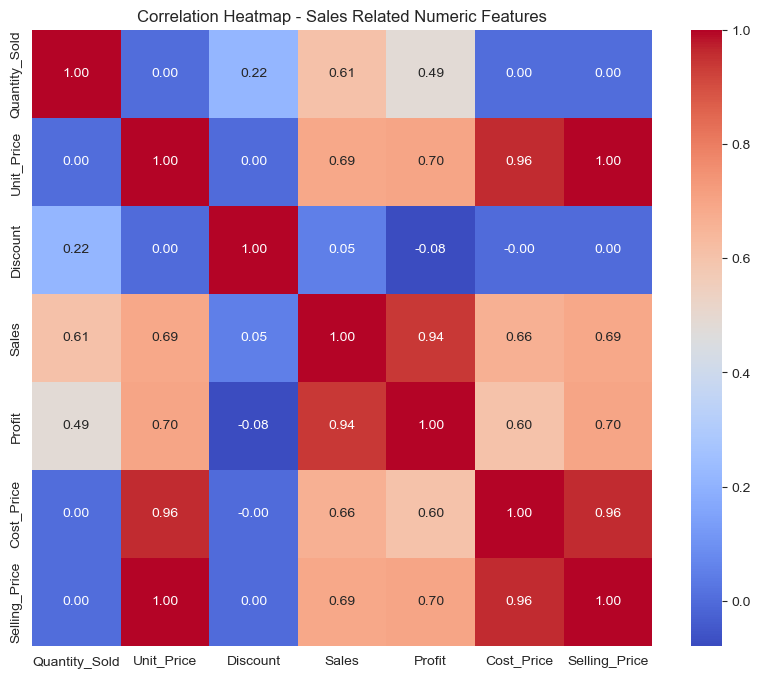

In [37]:
# ------------------------------------------------------------
# 11. CORRELATION ANALYSIS
# ------------------------------------------------------------
numeric_cols = sales_products[['Quantity_Sold','Unit_Price','Discount','Sales','Profit','Cost_Price','Selling_Price']]
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap - Sales Related Numeric Features")
plt.show()

In [38]:
print("EDA Completed Successfully")

EDA Completed Successfully
